In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-03-17 18:01:25.145822: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773770485.371215      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773770485.444314      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773770485.969726      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773770485.969775      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773770485.969808      55 computation_placer.cc:177] computation placer alr

In [2]:
train = pd.read_csv('/kaggle/input/datasets/bhavikjikadara/handwritten-digit-recognition/train.csv')

In [3]:
X = train.drop('label', axis=1).values
y = train['label'].values

In [4]:
X = X / 255.0

In [5]:
X = X.reshape(-1, 28, 28, 1)

In [11]:
y = to_categorical(y, 10)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

In [13]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

In [14]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_val, y_val),
    epochs=15
)

Epoch 1/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 64s 103ms/step - accuracy: 0.7244 - loss: 0.9032 - val_accuracy: 0.9760 - val_loss: 0.0859
Epoch 2/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 60s 102ms/step - accuracy: 0.9488 - loss: 0.1635 - val_accuracy: 0.9845 - val_loss: 0.0513
Epoch 3/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 60s 101ms/step - accuracy: 0.9658 - loss: 0.1171 - val_accuracy: 0.9831 - val_loss: 0.0479
Epoch 4/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 83s 103ms/step - accuracy: 0.9698 - loss: 0.1010 - val_accuracy: 0.9919 - val_loss: 0.0261
Epoch 5/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 61s 104ms/step - accuracy: 0.9746 - loss: 0.0810 - val_accuracy: 0.9893 - val_loss: 0.0293
Epoch 6/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 60s 102ms/step - accuracy: 0.9780 - loss: 0.0705 - val_accuracy: 0.9871 - val_loss: 0.0357
Epoch 7/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 60s 102ms/step - accuracy: 0.9790 - loss: 0.0668 - val_accuracy: 0.9881 - val_loss: 0.0378
Epoch 8/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 59s 101ms/step - accuracy: 0.9808 - loss: 0

In [17]:
loss, acc = model.evaluate(X_val, y_val)
print("Validation Accuracy:", acc)

132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9914 - loss: 0.0225
Validation Accuracy: 0.991428554058075


In [21]:
import matplotlib.pyplot as plt

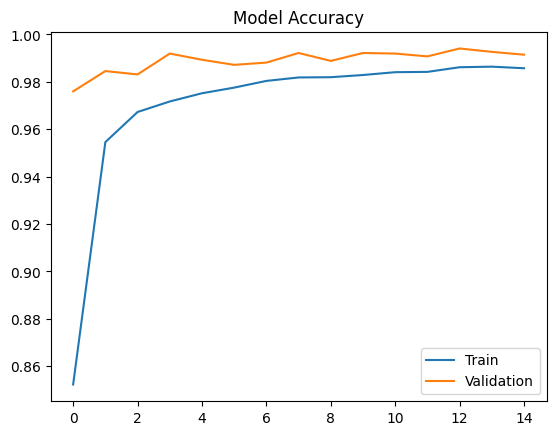

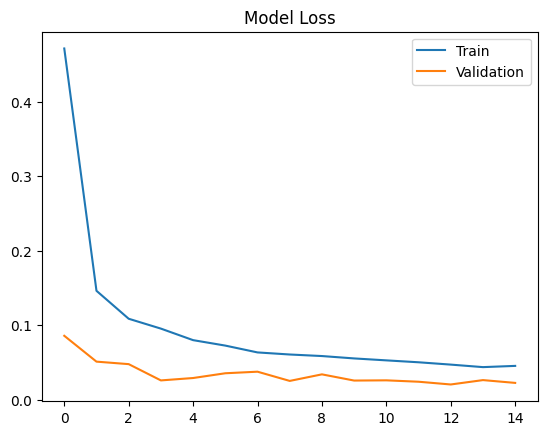

In [22]:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.legend(['Train', 'Validation'])
plt.show()

132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


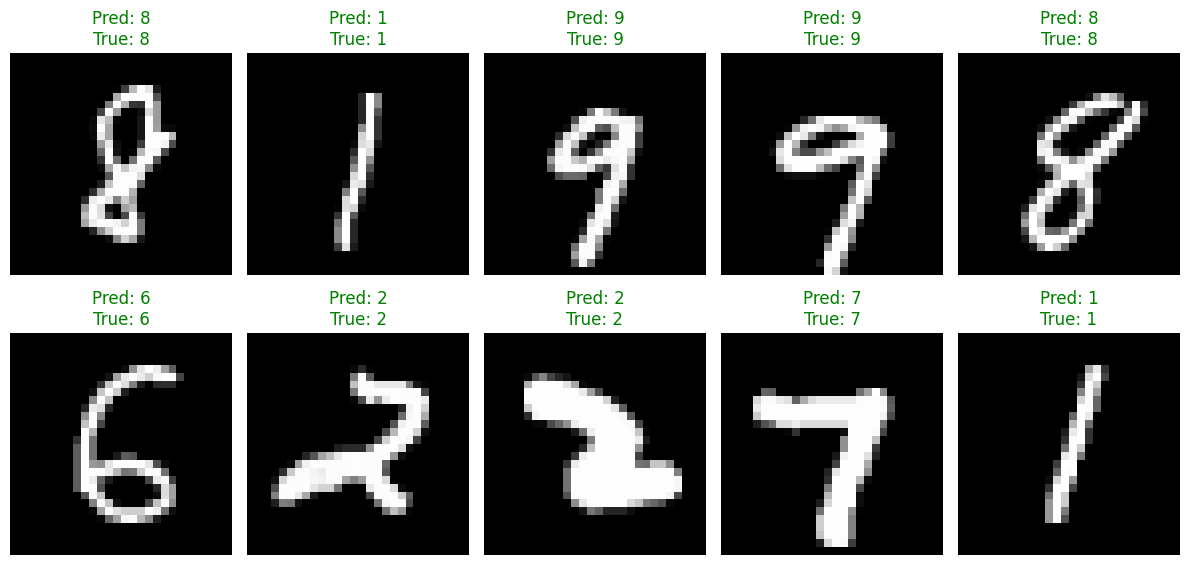

In [23]:

y_pred = model.predict(X_val)

# 🔹 2. Convert probabilities → labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

# 🔹 3. Plot comparison (Correct = Green, Wrong = Red)
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    
    img = X_val[i].reshape(28,28)
    plt.imshow(img, cmap='gray')
    
    pred = y_pred_classes[i]
    true = y_true[i]
    
    color = 'green' if pred == true else 'red'
    
    plt.title(f"Pred: {pred}\nTrue: {true}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()